# Final Modeling

This notebook builds the final modeling pipeline for **Workforce Risk Radar**.

We tested multiple models, but we do not want to deploy a model just because it looks good on training data.  
We want the model that is **most reliable on future months**.

### Final goal
We produce two practical outputs for the website:

1. **Final layoff prediction**
   - Predict monthly California WARN layoffs

2. **Final risk label**
   - Convert the predicted layoffs into Low / Medium / High risk

### Modeling decision
We will test:
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Logistic Regression
- Random Forest Classifier

Then we will choose the final website model based on the actual results, not on complexity.

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

## 1. Load the final master dataset

This dataset already combines:
- California WARN layoffs
- FRED macro indicators
- GDELT news features

In [35]:
master = pd.read_csv("../data/processed/master_monthly.csv")
master["month"] = pd.to_datetime(master["month"])
master = master.sort_values("month").reset_index(drop=True)

master.head()

,month,warn_layoffs,ca_unemployment_rate,fed_funds_rate,indeed_job_postings_index,news_volume,news_tone,warn_layoffs_log1p,news_volume_log1p,ca_unemployment_rate_lag1,...,news_volume_log1p_lag3,news_tone_lag1,news_tone_lag2,news_tone_lag3,warn_layoffs_z,ca_unemployment_rate_z,fed_funds_rate_z,indeed_job_postings_index_z,news_volume_z,news_tone_z
0,2020-07-01,32814,NaN,NaN,NaN,64201,-2.080829,10.398641,11.069790,NaN,...,NaN,NaN,NaN,NaN,5.268537,NaN,NaN,NaN,4.414589,-1.912911
1,2020-08-01,15544,NaN,NaN,NaN,47418,-2.014797,9.651494,10.766778,NaN,...,NaN,-2.080829,NaN,NaN,1.767228,NaN,NaN,NaN,2.807788,-1.633807
2,2020-09-01,14535,NaN,NaN,NaN,41715,-1.978027,9.584384,10.638640,NaN,...,NaN,-2.014797,-2.080829,NaN,1.562664,NaN,NaN,NaN,2.261784,-1.478387
3,2020-10-01,10477,NaN,NaN,NaN,27663,-1.937167,9.257033,10.227887,NaN,...,11.069790,-1.978027,-2.014797,-2.080829,0.739948,NaN,NaN,NaN,0.916448,-1.305681
4,2020-11-01,9323,NaN,NaN,NaN,19858,-1.985260,9.140347,9.896413,NaN,...,10.766778,-1.937167,-1.978027,-2.014797,0.505987,NaN,NaN,NaN,0.169199,-1.508961


## 2. Define the target and feature sets

We model `warn_layoffs_log1p` instead of raw layoffs because WARN counts are skewed.

We use lagged predictors because the project is about **early warning**, not just same-month association.

### Final feature sets to test
**Macro only**
- unemployment at lag 3
- fed funds at lag 1
- Indeed job postings at lag 1

**Macro + news**
- all macro features above
- news volume at lag 1
- news tone at lag 1

We are keeping this simple on purpose because the dataset is small.

In [36]:
master["warn_layoffs_log1p"] = np.log1p(master["warn_layoffs"])

macro_features = [
    "ca_unemployment_rate_lag3",
    "fed_funds_rate_lag1",
    "indeed_job_postings_index_lag1"
]

macro_news_features = macro_features + [
    "news_volume_log1p_lag1",
    "news_tone_lag1"
]

target_reg = "warn_layoffs_log1p"

print("Macro features:", macro_features)
print("Macro + news features:", macro_news_features)

Macro features: ['ca_unemployment_rate_lag3', 'fed_funds_rate_lag1', 'indeed_job_postings_index_lag1']
Macro + news features: ['ca_unemployment_rate_lag3', 'fed_funds_rate_lag1', 'indeed_job_postings_index_lag1', 'news_volume_log1p_lag1', 'news_tone_lag1']


## 3. Time-based train/test split

We keep the last 12 months as test data.

This is better than random splitting because the project is about predicting future time periods.

In [37]:
split_date = pd.Timestamp("2024-07-01")
master["split"] = np.where(master["month"] < split_date, "train", "test")

print(master["split"].value_counts())
print(master[["month", "split"]].tail(15))

split
train    48
test     12
Name: count, dtype: int64
        month  split
45 2024-04-01  train
46 2024-05-01  train
47 2024-06-01  train
48 2024-07-01   test
49 2024-08-01   test
50 2024-09-01   test
51 2024-10-01   test
52 2024-11-01   test
53 2024-12-01   test
54 2025-01-01   test
55 2025-02-01   test
56 2025-03-01   test
57 2025-04-01   test
58 2025-05-01   test
59 2025-06-01   test


## 4. Helper functions

In [38]:
def regression_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

def fit_and_eval_regression(train_df, test_df, features, target, model):
    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "model": model,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "train_metrics": regression_metrics(y_train, pred_train),
        "test_metrics": regression_metrics(y_test, pred_test)
    }

## 5. Prepare the regression datasets

We only drop rows that are missing the specific features needed for each model.

In [39]:
reg_macro_df = master.dropna(subset=macro_features + [target_reg]).copy()
reg_macro_news_df = master.dropna(subset=macro_news_features + [target_reg]).copy()

train_macro = reg_macro_df[reg_macro_df["split"] == "train"].copy()
test_macro = reg_macro_df[reg_macro_df["split"] == "test"].copy()

train_macro_news = reg_macro_news_df[reg_macro_news_df["split"] == "train"].copy()
test_macro_news = reg_macro_news_df[reg_macro_news_df["split"] == "test"].copy()

print("Macro train/test:", train_macro.shape, test_macro.shape)
print("Macro+news train/test:", train_macro_news.shape, test_macro_news.shape)

Macro train/test: (40, 34) (12, 34)
Macro+news train/test: (40, 34) (12, 34)


## 6. Fit the regression models

We test three models:

1. **Linear Regression (Macro only)**
   - simple baseline
   - easiest to interpret

2. **Ridge Regression (Macro + News)**
   - adds news features
   - helps control overfitting better than ordinary linear regression

3. **Random Forest Regressor (Macro + News)**
   - non-linear comparison
   - useful to check whether a more flexible model actually helps

In [40]:
tscv = TimeSeriesSplit(n_splits=4)

linear_model = LinearRegression()

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 25), cv=tscv))
])

rf_reg_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

In [41]:
reg_results = []

linear_out = fit_and_eval_regression(
    train_macro, test_macro, macro_features, target_reg, linear_model
)

reg_results.append({
    "model_name": "Linear Regression (Macro only)",
    "feature_set": "macro",
    "train_rmse": linear_out["train_metrics"]["rmse"],
    "test_rmse": linear_out["test_metrics"]["rmse"],
    "train_mae": linear_out["train_metrics"]["mae"],
    "test_mae": linear_out["test_metrics"]["mae"],
    "train_r2": linear_out["train_metrics"]["r2"],
    "test_r2": linear_out["test_metrics"]["r2"]
})

ridge_out = fit_and_eval_regression(
    train_macro_news, test_macro_news, macro_news_features, target_reg, ridge_model
)

reg_results.append({
    "model_name": "Ridge Regression (Macro + News)",
    "feature_set": "macro_news",
    "train_rmse": ridge_out["train_metrics"]["rmse"],
    "test_rmse": ridge_out["test_metrics"]["rmse"],
    "train_mae": ridge_out["train_metrics"]["mae"],
    "test_mae": ridge_out["test_metrics"]["mae"],
    "train_r2": ridge_out["train_metrics"]["r2"],
    "test_r2": ridge_out["test_metrics"]["r2"]
})

rf_reg_out = fit_and_eval_regression(
    train_macro_news, test_macro_news, macro_news_features, target_reg, rf_reg_model
)

reg_results.append({
    "model_name": "Random Forest Regressor (Macro + News)",
    "feature_set": "macro_news",
    "train_rmse": rf_reg_out["train_metrics"]["rmse"],
    "test_rmse": rf_reg_out["test_metrics"]["rmse"],
    "train_mae": rf_reg_out["train_metrics"]["mae"],
    "test_mae": rf_reg_out["test_metrics"]["mae"],
    "train_r2": rf_reg_out["train_metrics"]["r2"],
    "test_r2": rf_reg_out["test_metrics"]["r2"]
})

reg_metrics_df = pd.DataFrame(reg_results).sort_values("test_rmse").reset_index(drop=True)
reg_metrics_df

,model_name,feature_set,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Linear Regression (Macro only),macro,0.363297,0.359832,0.271989,0.262846,0.516602,-0.133571
1,Ridge Regression (Macro + News),macro_news,0.360066,0.413917,0.257167,0.330682,0.525161,-0.499944
2,Random Forest Regressor (Macro + News),macro_news,0.241144,0.473248,0.175980,0.358031,0.787022,-0.960763


## 7. Choose the final regression model

We choose the final model based on **test performance**, not training performance.

Why:
- a model can look great on training data and still fail on unseen months
- for the website, we want the model that generalizes best

If a simpler model wins, we will keep the simpler model.

In [42]:
best_regression_name = reg_metrics_df.iloc[0]["model_name"]
print("Chosen final regression model:", best_regression_name)

Chosen final regression model: Linear Regression (Macro only)


In [43]:
best_regression_name = reg_metrics_df.iloc[0]["model_name"]
best_regression_name

'Linear Regression (Macro only)'

## 8. Build final predictions from the chosen regression model

Our final website prediction should come from the best-performing regression model.

We keep only one final prediction output instead of showing all three models at once.

In [44]:
final_predictions = test_macro[[
    "month", "warn_layoffs", "warn_layoffs_log1p", "split"
]].copy()

final_predictions["pred_warn_layoffs_log1p"] = linear_out["pred_test"]
final_predictions["pred_warn_layoffs"] = np.expm1(final_predictions["pred_warn_layoffs_log1p"])

final_predictions.head()

,month,warn_layoffs,warn_layoffs_log1p,split,pred_warn_layoffs_log1p,pred_warn_layoffs
48,2024-07-01,4169,8.335671,test,8.869184,7108.477597
49,2024-08-01,4876,8.492286,test,8.867612,7097.309811
50,2024-09-01,7602,8.936298,test,8.867040,7093.254035
51,2024-10-01,7325,8.899185,test,8.828280,6823.537533
52,2024-11-01,9278,9.135509,test,8.767160,6418.914759


## 9. Final prediction plot

We show:
- actual WARN layoffs
- final model prediction

This is cleaner than showing all three models on the same website chart.

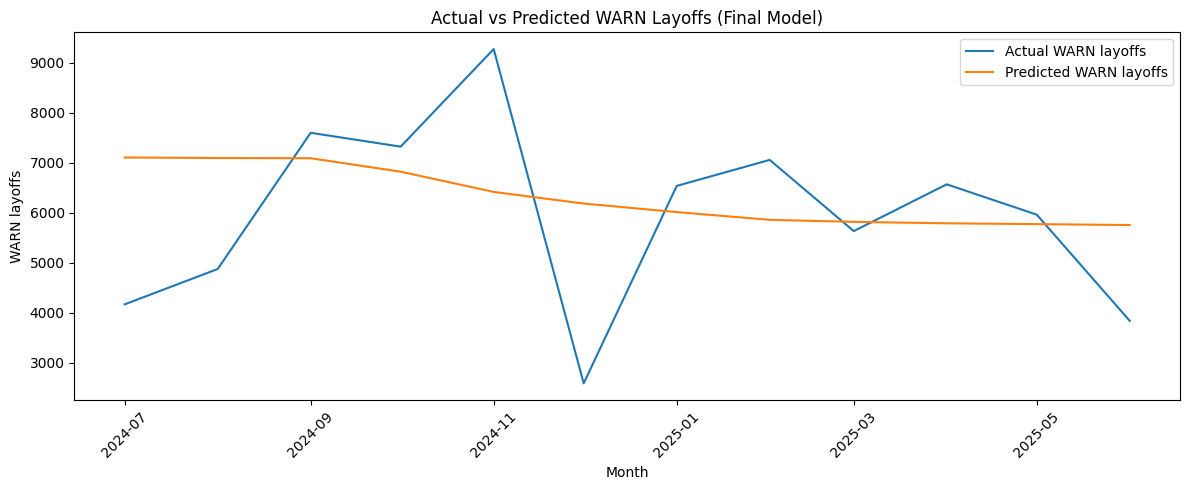

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(final_predictions["month"], final_predictions["warn_layoffs"], label="Actual WARN layoffs")
plt.plot(final_predictions["month"], final_predictions["pred_warn_layoffs"], label="Predicted WARN layoffs")

plt.title("Actual vs Predicted WARN Layoffs (Final Model)")
plt.xlabel("Month")
plt.ylabel("WARN layoffs")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/figures/final_actual_vs_predicted_warn.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Build risk thresholds from the training period only

We now turn the layoff prediction into a website-friendly risk level:
- Low
- Medium
- High

We compute the thresholds using only the training period so we do not use future information.

In [46]:
train_threshold_source = master[master["split"] == "train"]["warn_layoffs"]

q1 = train_threshold_source.quantile(1/3)
q2 = train_threshold_source.quantile(2/3)

print("q1 =", q1)
print("q2 =", q2)

q1 = 3845.6666666666665
q2 = 7062.333333333333


In [47]:
def assign_risk(x, q1, q2):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

## 11. Convert the regression output into final risk labels

This is our final website risk pipeline.

Important:
We are **not** using the classifier as the main deployed risk model, because the classification results were weak.
Instead, we use the stronger regression model and translate predicted layoffs into risk levels.

In [48]:
final_predictions["actual_risk_level"] = final_predictions["warn_layoffs"].apply(lambda x: assign_risk(x, q1, q2))
final_predictions["predicted_risk_level"] = final_predictions["pred_warn_layoffs"].apply(lambda x: assign_risk(x, q1, q2))

final_predictions.head()

,month,warn_layoffs,warn_layoffs_log1p,split,pred_warn_layoffs_log1p,pred_warn_layoffs,actual_risk_level,predicted_risk_level
48,2024-07-01,4169,8.335671,test,8.869184,7108.477597,Medium,High
49,2024-08-01,4876,8.492286,test,8.867612,7097.309811,Medium,High
50,2024-09-01,7602,8.936298,test,8.867040,7093.254035,High,High
51,2024-10-01,7325,8.899185,test,8.828280,6823.537533,High,Medium
52,2024-11-01,9278,9.135509,test,8.767160,6418.914759,High,Medium


## 12. Keep classification models as a comparison only

We still test classification models, because that is useful for documentation.

But if they perform poorly, we do not deploy them as the main risk engine.

In [49]:
clf_features = macro_news_features
clf_df = master.dropna(subset=clf_features + ["warn_layoffs"]).copy()

train_clf = clf_df[clf_df["split"] == "train"].copy()
test_clf = clf_df[clf_df["split"] == "test"].copy()

train_clf["risk_level"] = train_clf["warn_layoffs"].apply(lambda x: assign_risk(x, q1, q2))
test_clf["risk_level"] = test_clf["warn_layoffs"].apply(lambda x: assign_risk(x, q1, q2))

class_order = ["Low", "Medium", "High"]
train_clf["risk_level"] = pd.Categorical(train_clf["risk_level"], categories=class_order, ordered=True)
test_clf["risk_level"] = pd.Categorical(test_clf["risk_level"], categories=class_order, ordered=True)

X_train_clf = train_clf[clf_features]
X_test_clf = test_clf[clf_features]
y_train_clf = train_clf["risk_level"]
y_test_clf = test_clf["risk_level"]

print(train_clf.shape, test_clf.shape)

(40, 35) (12, 35)


In [50]:
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

rf_clf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

In [51]:
logit_model.fit(X_train_clf, y_train_clf)
rf_clf_model.fit(X_train_clf, y_train_clf)

pred_logit = logit_model.predict(X_test_clf)
pred_rf_clf = rf_clf_model.predict(X_test_clf)

clf_metrics = pd.DataFrame([
    {
        "model_name": "Logistic Regression",
        "accuracy": accuracy_score(y_test_clf, pred_logit),
        "precision_macro": precision_score(y_test_clf, pred_logit, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test_clf, pred_logit, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test_clf, pred_logit, average="macro", zero_division=0)
    },
    {
        "model_name": "Random Forest Classifier",
        "accuracy": accuracy_score(y_test_clf, pred_rf_clf),
        "precision_macro": precision_score(y_test_clf, pred_rf_clf, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test_clf, pred_rf_clf, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test_clf, pred_rf_clf, average="macro", zero_division=0)
    }
]).sort_values("f1_macro", ascending=False).reset_index(drop=True)

clf_metrics

,model_name,accuracy,precision_macro,recall_macro,f1_macro
0,Random Forest Classifier,0.416667,0.433333,0.428571,0.301994
1,Logistic Regression,0.416667,0.257143,0.301587,0.273810


## 13. Check the classifier

If the classifier performs weakly, we keep it as an experiment but do not use it as the main deployed output.

That is exactly why we compare models instead of assuming one will work.

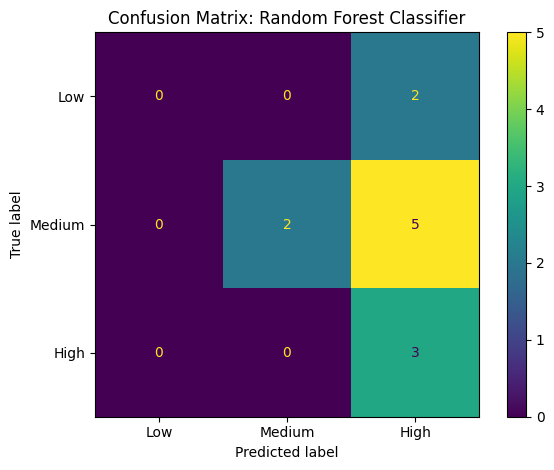

In [52]:
best_clf_name = clf_metrics.iloc[0]["model_name"]

if best_clf_name == "Logistic Regression":
    best_pred = pred_logit
else:
    best_pred = pred_rf_clf

cm = confusion_matrix(y_test_clf, best_pred, labels=class_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
disp.plot()
plt.title(f"Confusion Matrix: {best_clf_name}")
plt.tight_layout()
plt.show()

## 14. Final website-ready risk table

This is the file the website should use.

It includes:
- actual layoffs
- predicted layoffs
- actual risk level
- predicted risk level

In [53]:
final_risk_scores = final_predictions[[
    "month",
    "warn_layoffs",
    "pred_warn_layoffs",
    "actual_risk_level",
    "predicted_risk_level",
    "split"
]].copy()

final_risk_scores.head()

,month,warn_layoffs,pred_warn_layoffs,actual_risk_level,predicted_risk_level,split
48,2024-07-01,4169,7108.477597,Medium,High,test
49,2024-08-01,4876,7097.309811,Medium,High,test
50,2024-09-01,7602,7093.254035,High,High,test
51,2024-10-01,7325,6823.537533,High,Medium,test
52,2024-11-01,9278,6418.914759,High,Medium,test


## 15. Final model coefficients

Since the chosen final regression model is Linear Regression (Macro only),
we export its coefficients so the website and documentation match the model we actually selected.

In [54]:
feature_rows = []

# Final chosen model: Linear Regression
for feature, coef in zip(macro_features, linear_model.coef_):
    feature_rows.append({
        "model_name": "Linear Regression (Macro only)",
        "task": "final_regression",
        "feature": feature,
        "importance": coef
    })

# Comparison model: Ridge
ridge_final = ridge_out["model"].named_steps["ridge"]
for feature, coef in zip(macro_news_features, ridge_final.coef_):
    feature_rows.append({
        "model_name": "Ridge Regression (Macro + News)",
        "task": "comparison_regression",
        "feature": feature,
        "importance": coef
    })

# Comparison model: RF regressor
for feature, imp in zip(macro_news_features, rf_reg_model.feature_importances_):
    feature_rows.append({
        "model_name": "Random Forest Regressor (Macro + News)",
        "task": "comparison_regression",
        "feature": feature,
        "importance": imp
    })

# Comparison model: Logistic
logit_final = logit_model.named_steps["logit"]
logit_abs_mean = np.mean(np.abs(logit_final.coef_), axis=0)
for feature, coef in zip(clf_features, logit_abs_mean):
    feature_rows.append({
        "model_name": "Logistic Regression",
        "task": "comparison_classification",
        "feature": feature,
        "importance": coef
    })

# Comparison model: RF classifier
for feature, imp in zip(clf_features, rf_clf_model.feature_importances_):
    feature_rows.append({
        "model_name": "Random Forest Classifier",
        "task": "comparison_classification",
        "feature": feature,
        "importance": imp
    })

feature_importance_df = pd.DataFrame(feature_rows)
feature_importance_df.head(10)

,model_name,task,feature,importance
0,Linear Regression (Macro only),final_regression,ca_unemployment_rate_lag3,0.001422
1,Linear Regression (Macro only),final_regression,fed_funds_rate_lag1,0.184391
2,Linear Regression (Macro only),final_regression,indeed_job_postings_index_lag1,0.003808
3,Ridge Regression (Macro + News),comparison_regression,ca_unemployment_rate_lag3,-0.097137
4,Ridge Regression (Macro + News),comparison_regression,fed_funds_rate_lag1,0.145811
5,Ridge Regression (Macro + News),comparison_regression,indeed_job_postings_index_lag1,-0.075153
6,Ridge Regression (Macro + News),comparison_regression,news_volume_log1p_lag1,0.037493
7,Ridge Regression (Macro + News),comparison_regression,news_tone_lag1,-0.064157
8,Random Forest Regressor (Macro + News),comparison_regression,ca_unemployment_rate_lag3,0.075339
9,Random Forest Regressor (Macro + News),comparison_regression,fed_funds_rate_lag1,0.706365


## 16. Refit the final regression model on all usable rows

Up to this point, we used a train/test split to compare models fairly.

Now that we have chosen the final deployed model, we refit that model on all usable rows
so the website can use the full available history rather than only the test period.

Chosen final model:
- Linear Regression (Macro only)

In [57]:
# Use all usable rows for the chosen final model
final_reg_df = master.dropna(subset=macro_features + [target_reg]).copy()

X_final = final_reg_df[macro_features]
y_final = final_reg_df[target_reg]

final_linear_model = LinearRegression()
final_linear_model.fit(X_final, y_final)

print("Rows used for final deployed regression model:", final_reg_df.shape[0])

Rows used for final deployed regression model: 52


## 17. Build full website-ready prediction table

This table is for the website.

It contains:
- actual WARN layoffs
- predicted WARN layoffs from the final deployed model
- actual risk level
- predicted risk level

Unlike the earlier evaluation table, this one covers the full usable timeline for the chosen model.

In [59]:
website_predictions = final_reg_df[[
    "month",
    "warn_layoffs",
    "warn_layoffs_log1p",
    "split"
]].copy()

website_predictions["pred_warn_layoffs_log1p"] = final_linear_model.predict(X_final)
website_predictions["pred_warn_layoffs"] = np.expm1(website_predictions["pred_warn_layoffs_log1p"])

website_predictions["actual_risk_level"] = website_predictions["warn_layoffs"].apply(lambda x: assign_risk(x, q1, q2))
website_predictions["predicted_risk_level"] = website_predictions["pred_warn_layoffs"].apply(lambda x: assign_risk(x, q1, q2))

website_predictions.head()

,month,warn_layoffs,warn_layoffs_log1p,split,pred_warn_layoffs_log1p,pred_warn_layoffs,actual_risk_level,predicted_risk_level
8,2021-03-01,3848,8.255569,train,7.826668,2505.564315,Medium,Low
9,2021-04-01,4122,8.324336,train,7.902674,2703.504932,Medium,Low
10,2021-05-01,2720,7.908755,train,7.990285,2951.137156,Low,Low
11,2021-06-01,1672,7.422374,train,8.041580,3106.520630,Low,Low
12,2021-07-01,2616,7.869784,train,8.080139,3228.683477,Low,Low


## 18. Build the final website risk table

This is the main file the website should read for:
- latest risk level
- actual vs predicted layoffs
- historical risk trend

In [60]:
website_risk_scores = website_predictions[[
    "month",
    "warn_layoffs",
    "pred_warn_layoffs",
    "actual_risk_level",
    "predicted_risk_level",
    "split"
]].copy()

website_risk_scores.tail(12)

,month,warn_layoffs,pred_warn_layoffs,actual_risk_level,predicted_risk_level,split
48,2024-07-01,4169,6648.439451,Medium,Medium,test
49,2024-08-01,4876,6586.872712,Medium,Medium,test
50,2024-09-01,7602,6846.336408,High,Medium,test
51,2024-10-01,7325,6693.740541,High,Medium,test
52,2024-11-01,9278,6157.978845,High,Medium,test
53,2024-12-01,2588,5635.325901,Low,Medium,test
54,2025-01-01,6539,5478.275077,Medium,Medium,test
55,2025-02-01,7060,5338.824388,Medium,Medium,test
56,2025-03-01,5635,5194.448510,Medium,Medium,test
57,2025-04-01,6571,5224.523563,Medium,Medium,test


## 19. Final website plot

This plot uses the refit final model on all usable rows.

For the website, this is more useful than showing only the test-period predictions.

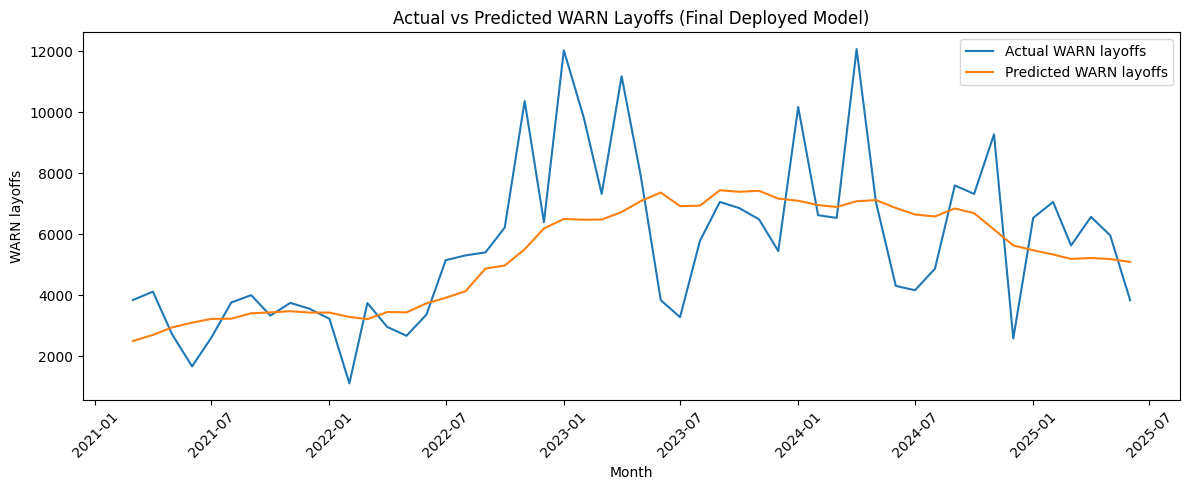

In [62]:
plt.figure(figsize=(12, 5))
plt.plot(website_predictions["month"], website_predictions["warn_layoffs"], label="Actual WARN layoffs")
plt.plot(website_predictions["month"], website_predictions["pred_warn_layoffs"], label="Predicted WARN layoffs")

plt.title("Actual vs Predicted WARN Layoffs (Final Deployed Model)")
plt.xlabel("Month")
plt.ylabel("WARN layoffs")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/figures/final_website_actual_vs_predicted_warn.png", dpi=300, bbox_inches="tight")
plt.show()

## 20. Final model coefficients

Since the final deployed model is Linear Regression (Macro only), we export its coefficients.

Note:
These are model coefficients, not standardized feature importance values.
They should be interpreted as model weights, not direct one-to-one importance rankings across different feature scales.

In [64]:
final_model_coefficients = pd.DataFrame({
    "feature": macro_features,
    "coefficient": final_linear_model.coef_
}).sort_values("coefficient", key=lambda s: np.abs(s), ascending=False)

final_model_coefficients

,feature,coefficient
1,fed_funds_rate_lag1,0.233785
0,ca_unemployment_rate_lag3,0.060307
2,indeed_job_postings_index_lag1,0.008711


## 21. Save final outputs for the website

These files will feed the dashboard later.

In [65]:
os.makedirs("../data/processed", exist_ok=True)

# evaluation outputs
regression_metrics_final = reg_metrics_df.copy()
classification_metrics_final = clf_metrics.copy()

# website-ready outputs from the refit final model
website_predictions.to_csv("../data/processed/final_predictions.csv", index=False)
website_risk_scores.to_csv("../data/processed/final_risk_scores.csv", index=False)

# supporting outputs
regression_metrics_final.to_csv("../data/processed/regression_metrics.csv", index=False)
classification_metrics_final.to_csv("../data/processed/classification_metrics.csv", index=False)
final_model_coefficients.to_csv("../data/processed/final_model_coefficients.csv", index=False)

print("Saved:")
print("- ../data/processed/final_predictions.csv")
print("- ../data/processed/final_risk_scores.csv")
print("- ../data/processed/regression_metrics.csv")
print("- ../data/processed/classification_metrics.csv")
print("- ../data/processed/final_model_coefficients.csv")
print("- ../data/processed/figures/final_website_actual_vs_predicted_warn.png")

Saved:
- ../data/processed/final_predictions.csv
- ../data/processed/final_risk_scores.csv
- ../data/processed/regression_metrics.csv
- ../data/processed/classification_metrics.csv
- ../data/processed/final_model_coefficients.csv
- ../data/processed/figures/final_website_actual_vs_predicted_warn.png


## 22. Final modeling conclusion

### Final regression model
**Linear Regression (Macro only)**

Why we chose it:
- it had the best test RMSE
- it generalized better than the more complex models
- it is easier to explain and safer to deploy

### Final website risk logic
We use the regression prediction and convert it into:
- Low
- Medium
- High

Why we chose this:
- the classifier results were weaker
- the regression model was more reliable
- this gives us a cleaner and more defensible website output

For deployment, the website should use:
- `final_predictions.csv`
- `final_risk_scores.csv`
- `regression_metrics.csv`
- `classification_metrics.csv`
- `final_model_coefficients.csv`


Main deployed risk logic:
- convert predicted WARN layoffs into Low / Medium / High using training-period thresholds